# Credit Card Transactions — Fraud Detection & CLV Modeling
**Project:** Customer Spending Intelligence | Fintech Portfolio Project  
**Phase:** 3 of 4 — Fraud Classification + Customer Lifetime Value Regression  
**Inputs:** `credit_card_transactions.csv` (1.3M rows) · `customer_segments.csv` (983 customers)  
**Outputs:** `fraud_model.json` · `clv_model.json` · SHAP plots · evaluation report  
**Author:** Shrey Sheth  
**Runtime:** Google Colab Pro (T4/A100 GPU — CPU-only also works, ~5 min slower)

---

## Notebook map
| Section | What it does |
|---|---|
| 0 | Install & imports |
| 1 | Load & merge data |
| 2 | Feature engineering (transaction-level) |
| 3 | Train/test split — stratified by segment |
| 4 | Handle class imbalance with SMOTE |
| 5 | XGBoost fraud classifier — baseline |
| 6 | Hyperparameter tuning (RandomizedSearchCV) |
| 7 | Final model evaluation — PR-AUC, confusion matrix, threshold analysis |
| 8 | SHAP feature importance |
| 9 | CLV regression (bonus) |
| 10 | Save models + Phase 3 summary |

> **Metric choice:** We use **Precision-Recall AUC** as the primary metric, not accuracy.  
> A naïve "always predict not-fraud" classifier scores 99.4% accuracy on this dataset and catches zero fraud.  
> PR-AUC rewards models that are both precise (few false alarms) and recall-high (few missed frauds).


---
## 0. Install & Imports

In [1]:
# Run this cell first — installs packages not in Colab by default
!pip install xgboost shap imbalanced-learn --quiet


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
import os
import json
import time

# Modelling
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    precision_recall_curve, average_precision_score,
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve, f1_score,
    mean_absolute_error, mean_squared_error, r2_score
)
from sklearn.linear_model import LinearRegression
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import xgboost as xgb
import shap

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
warnings.filterwarnings('ignore')

os.makedirs('plots', exist_ok=True)
np.random.seed(42)

print(f'XGBoost version : {xgb.__version__}')
print(f'SHAP version    : {shap.__version__}')
print('Setup complete.')


XGBoost version : 3.2.0
SHAP version    : 0.51.0
Setup complete.


---
## 1. Load & Merge Data

We work at two levels in this notebook:
- **Transaction level** (1.3M rows) — for fraud classification
- **Customer level** (983 rows) — for CLV regression

The segment labels from Phase 2 are merged into the transaction table so the cluster identity
becomes a feature in the fraud model.

> **Colab tip:** Upload both CSV files via the Files panel on the left, or mount Google Drive:
> ```python
> from google.colab import drive
> drive.mount('/content/drive')
> ```


In [3]:
# ── Load transaction-level data ──
print('Loading transactions...')
t0 = time.time()

txn = pd.read_csv(
    'credit_card_transactions.csv',
    parse_dates=['trans_date_trans_time', 'dob']
)
if 'Unnamed: 0' in txn.columns:
    txn.drop(columns=['Unnamed: 0'], inplace=True)

print(f'Transactions loaded: {txn.shape}  ({time.time()-t0:.1f}s)')
print(f'Memory: {txn.memory_usage(deep=True).sum()/1e6:.0f} MB')
print(f'Fraud rate: {txn["is_fraud"].mean()*100:.3f}%')


Loading transactions...
Transactions loaded: (1296675, 23)  (7.2s)
Memory: 941 MB
Fraud rate: 0.579%


In [4]:
# ── Load customer segments from Phase 2 ──
seg = pd.read_csv('customer_segments.csv')
print(f'Customer segments loaded: {seg.shape}')
print(seg['segment_name'].value_counts())


Customer segments loaded: (983, 24)
segment_name
Loyal         512
Champions     396
Dormant        41
Suspicious     34
Name: count, dtype: int64


In [5]:
# ── Merge segment label into transaction table ──
seg_map = seg[['cc_num', 'cluster', 'segment_name']].drop_duplicates()
txn = txn.merge(seg_map, on='cc_num', how='left')

# Fill any cc_num not in segments (shouldn't happen, but safe)
txn['cluster'] = txn['cluster'].fillna(-1).astype(int)
txn['segment_name'] = txn['segment_name'].fillna('Unknown')

print(f'Merge complete. Transactions with segment: {(txn["cluster"] != -1).sum():,}')
print(txn['segment_name'].value_counts())


Merge complete. Transactions with segment: 1,296,675
segment_name
Champions     816718
Loyal         479216
Dormant          403
Suspicious       338
Name: count, dtype: int64


---
## 2. Feature Engineering — Transaction Level

> We rebuild the same time features from Phase 1, plus add a few new ones specifically
> designed as fraud signals. The key additions are:
> - `hour_sin` / `hour_cos` — cyclical encoding of hour (so 23 and 0 are close, not far apart)
> - `is_night` — binary flag for 12am–6am window
> - `amt_z_customer` — how many standard deviations this transaction's amount is from that
>   customer's own mean. A $900 txn for someone who usually spends $50 is very different
>   from a $900 txn for a high-roller.
> - `distance_km` — Haversine cardholder-to-merchant distance (recomputed)


In [6]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return R * 2 * np.arcsin(np.sqrt(a))

print('Engineering features...')
t0 = time.time()

# Time features
txn['hour']         = txn['trans_date_trans_time'].dt.hour
txn['dow']          = txn['trans_date_trans_time'].dt.dayofweek
txn['month']        = txn['trans_date_trans_time'].dt.month
txn['is_weekend']   = txn['dow'].isin([5, 6]).astype(int)
txn['is_night']     = txn['hour'].between(0, 5).astype(int)

# Cyclical hour encoding — preserves continuity across midnight
txn['hour_sin']     = np.sin(2 * np.pi * txn['hour'] / 24)
txn['hour_cos']     = np.cos(2 * np.pi * txn['hour'] / 24)

# Customer age
txn['age'] = ((txn['trans_date_trans_time'] - txn['dob']).dt.days / 365.25).astype(int)

# Distance
txn['distance_km'] = haversine(txn['lat'], txn['long'], txn['merch_lat'], txn['merch_long'])

# Per-customer amount z-score — deviation from that customer's own spending norm
cust_stats = txn.groupby('cc_num')['amt'].agg(['mean', 'std']).rename(
    columns={'mean': 'cust_mean_amt', 'std': 'cust_std_amt'})
txn = txn.merge(cust_stats, on='cc_num', how='left')
txn['cust_std_amt'] = txn['cust_std_amt'].fillna(1)
txn['amt_z_customer'] = (txn['amt'] - txn['cust_mean_amt']) / txn['cust_std_amt'].replace(0, 1)

# Log-transform amount (reduce skew)
txn['log_amt'] = np.log1p(txn['amt'])

# Encode gender
txn['gender_enc'] = (txn['gender'] == 'M').astype(int)

# Encode category
le_cat = LabelEncoder()
txn['category_enc'] = le_cat.fit_transform(txn['category'])

print(f'Feature engineering done in {time.time()-t0:.1f}s')
print(f'Dataset shape: {txn.shape}')


Engineering features...
Feature engineering done in 1.8s
Dataset shape: (1296675, 40)


---
## 3. Train / Test Split — Stratified by Segment

> We use `stratify=y` to ensure both train and test sets have the same fraud rate (~0.58%).
> Without stratification, random splitting on an imbalanced dataset can put almost all fraud
> cases in one split.
>
> We also do a 70/30 split rather than 80/20 — with 1.3M rows, 30% test (~390K rows) gives
> us a large enough test set to get stable PR-AUC estimates.


In [7]:
# Final feature set for fraud classification
FRAUD_FEATURES = [
    # Amount
    'log_amt', 'amt_z_customer',
    # Time signals
    'hour', 'hour_sin', 'hour_cos', 'dow', 'month', 'is_weekend', 'is_night',
    # Geography
    'distance_km',
    # Customer
    'age', 'gender_enc', 'city_pop',
    # Merchant
    'category_enc',
    # Segment from Phase 2
    'cluster',
]

TARGET = 'is_fraud'

# Drop rows with any NaN in features (shouldn't be many)
model_df = txn[FRAUD_FEATURES + [TARGET]].dropna()
print(f'Modelling dataset: {model_df.shape}')
print(f'Fraud cases: {model_df[TARGET].sum():,} ({model_df[TARGET].mean()*100:.3f}%)')

X = model_df[FRAUD_FEATURES].values
y = model_df[TARGET].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print(f'Train: {X_train.shape}  |  fraud: {y_train.sum():,} ({y_train.mean()*100:.3f}%)')
print(f'Test : {X_test.shape}   |  fraud: {y_test.sum():,} ({y_test.mean()*100:.3f}%)')


Modelling dataset: (1296675, 16)
Fraud cases: 7,506 (0.579%)
Train: (907672, 15)  |  fraud: 5,254 (0.579%)
Test : (389003, 15)   |  fraud: 2,252 (0.579%)


---
## 4. Handle Class Imbalance — SMOTE

> **Why SMOTE and not just class_weight?**  
> XGBoost's `scale_pos_weight` parameter adjusts the loss function to penalise missed fraud
> more heavily — it's fast and often sufficient. SMOTE (Synthetic Minority Over-sampling
> Technique) goes further by *generating new synthetic fraud examples* in feature space,
> giving the model more diverse fraud patterns to learn from.
>
> We apply SMOTE **only to the training set** — never the test set.
> Applying SMOTE to the test set would be data leakage and would inflate all metrics.
>
> We target a 10:1 ratio (not 1:1) — full balancing often hurts precision on this type
> of data because the synthetic samples start overlapping with legitimate transactions.


In [8]:
print('Applying SMOTE to training set...')
print(f'Before — fraud: {y_train.sum():,}  |  legit: {(y_train==0).sum():,}')
t0 = time.time()

# 10:1 ratio — for every 10 legit, 1 fraud
fraud_count = y_train.sum()
legit_count = (y_train == 0).sum()
target_fraud = legit_count // 10

smote = SMOTE(
    sampling_strategy={1: target_fraud},
    random_state=42,
    k_neighbors=5
)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f'After  — fraud: {y_train_res.sum():,}  |  legit: {(y_train_res==0).sum():,}')
print(f'New fraud rate in train: {y_train_res.mean()*100:.2f}%')
print(f'SMOTE done in {time.time()-t0:.1f}s')


Applying SMOTE to training set...
Before — fraud: 5,254  |  legit: 902,418
After  — fraud: 90,241  |  legit: 902,418
New fraud rate in train: 9.09%
SMOTE done in 0.2s


---
## 5. Baseline XGBoost Classifier

> We train a baseline model with reasonable defaults before tuning.
> This gives us a floor to beat in Section 6, and lets us verify the pipeline is working.
>
> Key XGBoost parameters at baseline:
> - `tree_method='hist'` — faster histogram-based algorithm, works on GPU with `device='cuda'`
> - `eval_metric='aucpr'` — tracks PR-AUC during training so we can see if it's improving
> - `early_stopping_rounds=20` — stops training if PR-AUC on the eval set doesn't improve


In [9]:
# Detect GPU availability
import subprocess
try:
    result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
    has_gpu = result.returncode == 0
except:
    has_gpu = False

device = 'cuda' if has_gpu else 'cpu'
print(f'Device: {device}')

# Baseline model
baseline_params = {
    'n_estimators'    : 500,
    'learning_rate'   : 0.05,
    'max_depth'       : 6,
    'subsample'       : 0.8,
    'colsample_bytree': 0.8,
    'min_child_weight': 5,
    'tree_method'     : 'hist',
    'device'          : device,
    'random_state'    : 42,
    'eval_metric'     : 'aucpr',
    'early_stopping_rounds': 20,
}

print('Training baseline XGBoost...')
t0 = time.time()

baseline = xgb.XGBClassifier(**baseline_params)
baseline.fit(
    X_train_res, y_train_res,
    eval_set=[(X_test, y_test)],
    verbose=50
)

print(f'Training done in {time.time()-t0:.1f}s')

# Evaluate
y_prob_base = baseline.predict_proba(X_test)[:, 1]
pr_auc_base = average_precision_score(y_test, y_prob_base)
roc_auc_base = roc_auc_score(y_test, y_prob_base)

print(f'\nBaseline results:')
print(f'  PR-AUC  : {pr_auc_base:.4f}')
print(f'  ROC-AUC : {roc_auc_base:.4f}')


Device: cuda
Training baseline XGBoost...
[0]	validation_0-aucpr:0.51427
[50]	validation_0-aucpr:0.72639
[100]	validation_0-aucpr:0.79144
[150]	validation_0-aucpr:0.84295
[200]	validation_0-aucpr:0.87572
[250]	validation_0-aucpr:0.89430
[300]	validation_0-aucpr:0.90582
[350]	validation_0-aucpr:0.91758
[400]	validation_0-aucpr:0.92433
[450]	validation_0-aucpr:0.93182
[499]	validation_0-aucpr:0.93507
Training done in 5.9s

Baseline results:
  PR-AUC  : 0.9351
  ROC-AUC : 0.9985


---
## 6. Hyperparameter Tuning — RandomizedSearchCV

> We use `RandomizedSearchCV` rather than `GridSearchCV` — with XGBoost the search space
> is large and exhaustive grid search would take hours. Randomized search samples 30
> parameter combinations and is typically 90%+ as effective at finding good hyperparameters.
>
> **Scoring metric:** `average_precision` = PR-AUC. This is the correct choice for imbalanced
> classification — it directly optimises what we care about.
>
> **CV strategy:** `StratifiedKFold(n_splits=3)` — 3-fold keeps runtime reasonable on 1.3M rows
> while still giving reliable estimates. Use 5-fold if you have time.


In [10]:
param_dist = {
    'n_estimators'    : [300, 500, 700, 1000],
    'learning_rate'   : [0.01, 0.03, 0.05, 0.1],
    'max_depth'       : [4, 5, 6, 7, 8],
    'subsample'       : [0.6, 0.7, 0.8, 0.9],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5, 10, 20],
    'gamma'           : [0, 0.1, 0.2, 0.5, 1.0],
    'reg_alpha'       : [0, 0.01, 0.1, 1.0],
    'reg_lambda'      : [0.1, 1.0, 5.0, 10.0],
}

xgb_base = xgb.XGBClassifier(
    tree_method='hist',
    device=device,
    random_state=42,
    eval_metric='aucpr',
)

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=30,
    scoring='average_precision',
    cv=cv,
    refit=True,
    verbose=2,
    random_state=42,
    n_jobs=-1,
)

print('Running RandomizedSearchCV (n_iter=30, cv=3)...')
print('Estimated time: 10–20 min on CPU, 3–7 min on GPU')
t0 = time.time()

search.fit(X_train_res, y_train_res)

print(f'\nSearch complete in {(time.time()-t0)/60:.1f} min')
print(f'Best CV PR-AUC : {search.best_score_:.4f}')
print(f'Best params    :')
for k, v in search.best_params_.items():
    print(f'  {k:25s}: {v}')


Running RandomizedSearchCV (n_iter=30, cv=3)...
Estimated time: 10–20 min on CPU, 3–7 min on GPU
Fitting 3 folds for each of 30 candidates, totalling 90 fits

Search complete in 5.4 min
Best CV PR-AUC : 0.9995
Best params    :
  subsample                : 0.9
  reg_lambda               : 1.0
  reg_alpha                : 0.01
  n_estimators             : 700
  min_child_weight         : 3
  max_depth                : 6
  learning_rate            : 0.1
  gamma                    : 0
  colsample_bytree         : 0.8


In [11]:
# CV results — show top 10 parameter combinations
cv_results = pd.DataFrame(search.cv_results_)
top10 = (cv_results
    .sort_values('mean_test_score', ascending=False)
    .head(10)[['mean_test_score', 'std_test_score', 'params']]
    .reset_index(drop=True)
)
top10['mean_test_score'] = top10['mean_test_score'].round(4)
top10['std_test_score']  = top10['std_test_score'].round(4)
print('Top 10 parameter combinations by CV PR-AUC:')
print(top10.to_string())


Top 10 parameter combinations by CV PR-AUC:
   mean_test_score  std_test_score                                                                                                                                                                              params
0           0.9995          0.0001     {'subsample': 0.9, 'reg_lambda': 1.0, 'reg_alpha': 0.01, 'n_estimators': 700, 'min_child_weight': 3, 'max_depth': 6, 'learning_rate': 0.1, 'gamma': 0, 'colsample_bytree': 0.8}
1           0.9995          0.0001   {'subsample': 0.7, 'reg_lambda': 1.0, 'reg_alpha': 0.01, 'n_estimators': 700, 'min_child_weight': 3, 'max_depth': 6, 'learning_rate': 0.1, 'gamma': 0.2, 'colsample_bytree': 0.8}
2           0.9995          0.0001     {'subsample': 0.8, 'reg_lambda': 0.1, 'reg_alpha': 0, 'n_estimators': 700, 'min_child_weight': 1, 'max_depth': 6, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 0.6}
3           0.9994          0.0001   {'subsample': 0.9, 'reg_lambda': 10.0, 'reg_alpha': 1.0, 'n

---
## 7. Final Model Evaluation

> The tuned model from Section 6 is evaluated on the held-out test set (30% of original data,
> never seen during training or SMOTE). We report:
> - **PR curve** — the primary visual for imbalanced classifiers
> - **ROC curve** — included for completeness
> - **Confusion matrix** at the default 0.5 threshold and at the optimal F1 threshold
> - **Threshold analysis** — shows how precision, recall, and F1 trade off across thresholds
>
> In production, the operating threshold should be chosen based on business cost:
> how much does a missed fraud cost vs how much does a false alarm (blocked legitimate
> transaction) cost?


In [12]:
best_model = search.best_estimator_

# Predictions
y_prob  = best_model.predict_proba(X_test)[:, 1]
y_pred  = best_model.predict(X_test)

# Core metrics
pr_auc  = average_precision_score(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

print('=== FINAL MODEL EVALUATION ===')
print(f'PR-AUC  (primary) : {pr_auc:.4f}')
print(f'ROC-AUC           : {roc_auc:.4f}')
print(f'Baseline PR-AUC   : {pr_auc_base:.4f}  (delta: +{pr_auc - pr_auc_base:.4f})')
print()
print('Classification report (threshold=0.5):')
print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Fraud'], digits=4))


=== FINAL MODEL EVALUATION ===
PR-AUC  (primary) : 0.9497
ROC-AUC           : 0.9988
Baseline PR-AUC   : 0.9351  (delta: +0.0146)

Classification report (threshold=0.5):
              precision    recall  f1-score   support

  Legitimate     0.9992    0.9998    0.9995    386751
       Fraud     0.9549    0.8548    0.9021      2252

    accuracy                         0.9989    389003
   macro avg     0.9770    0.9273    0.9508    389003
weighted avg     0.9989    0.9989    0.9989    389003



In [13]:
# ── Optimal threshold by F1 ──
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-8)
best_thresh_idx = np.argmax(f1_scores)
best_threshold  = thresholds[best_thresh_idx]
best_f1         = f1_scores[best_thresh_idx]

print(f'Optimal threshold (max F1): {best_threshold:.4f}')
print(f'At this threshold:')
y_pred_opt = (y_prob >= best_threshold).astype(int)
print(classification_report(y_test, y_pred_opt, target_names=['Legitimate', 'Fraud'], digits=4))


Optimal threshold (max F1): 0.4488
At this threshold:
              precision    recall  f1-score   support

  Legitimate     0.9992    0.9997    0.9995    386751
       Fraud     0.9473    0.8623    0.9028      2252

    accuracy                         0.9989    389003
   macro avg     0.9733    0.9310    0.9511    389003
weighted avg     0.9989    0.9989    0.9989    389003



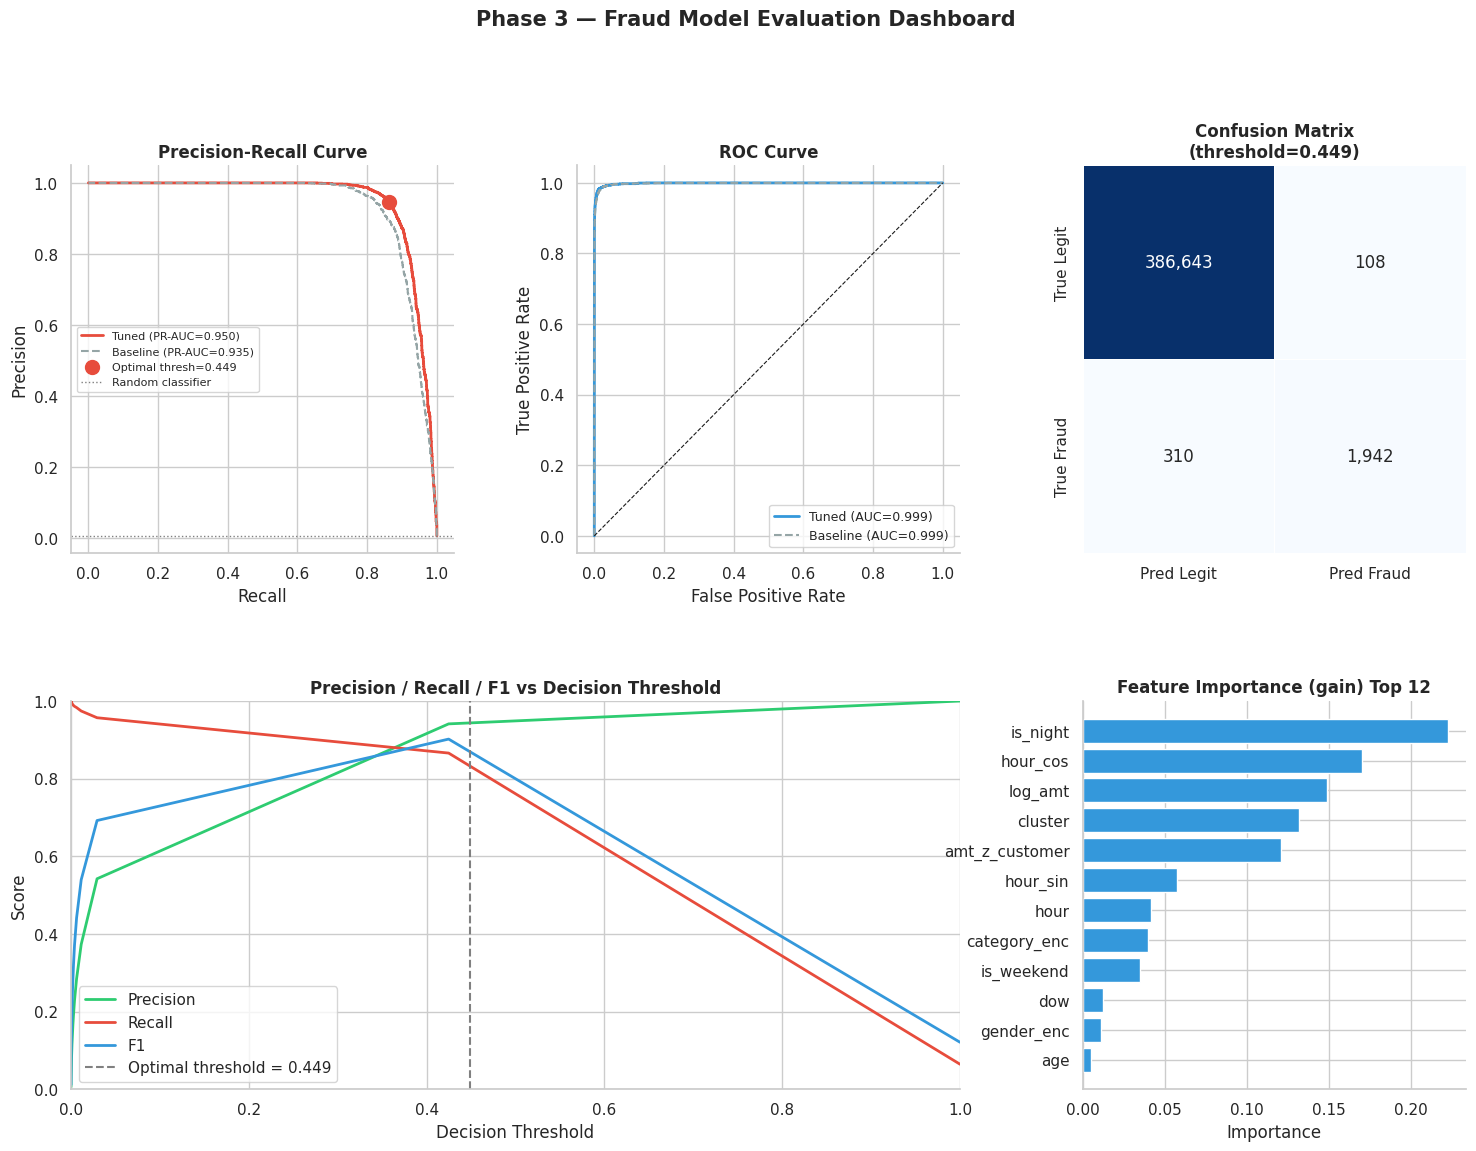


Saved: plots/20_model_evaluation.png


In [16]:
# ── Full evaluation plot: PR curve + ROC + Confusion matrix + Threshold analysis ──
fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.38, wspace=0.32)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])
ax4 = fig.add_subplot(gs[1, :2])
ax5 = fig.add_subplot(gs[1, 2])

# 1. PR Curve
ax1.plot(recalls[:-1], precisions[:-1], color='#e74c3c', linewidth=2,
         label=f'Tuned (PR-AUC={pr_auc:.3f})')
# Baseline PR
prec_b, rec_b, _ = precision_recall_curve(y_test, y_prob_base)
ax1.plot(rec_b[:-1], prec_b[:-1], color='#95a5a6', linewidth=1.5, linestyle='--',
         label=f'Baseline (PR-AUC={pr_auc_base:.3f})')
ax1.scatter(recalls[best_thresh_idx], precisions[best_thresh_idx],
            color='#e74c3c', s=100, zorder=5, label=f'Optimal thresh={best_threshold:.3f}')
ax1.axhline(y_test.mean(), color='gray', linestyle=':', linewidth=1, label='Random classifier')
ax1.set_xlabel('Recall'); ax1.set_ylabel('Precision')
ax1.set_title('Precision-Recall Curve', fontweight='bold')
ax1.legend(fontsize=8)

# 2. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
fpr_b, tpr_b, _ = roc_curve(y_test, y_prob_base)
ax2.plot(fpr, tpr, color='#3498db', linewidth=2, label=f'Tuned (AUC={roc_auc:.3f})')
ax2.plot(fpr_b, tpr_b, color='#95a5a6', linewidth=1.5, linestyle='--',
         label=f'Baseline (AUC={roc_auc_base:.3f})')
ax2.plot([0,1],[0,1], 'k--', linewidth=0.8)
ax2.set_xlabel('False Positive Rate'); ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curve', fontweight='bold')
ax2.legend(fontsize=9)

# 3. Confusion matrix at optimal threshold
cm = confusion_matrix(y_test, y_pred_opt)
sns.heatmap(cm, annot=True, fmt=',', cmap='Blues', ax=ax3,
            xticklabels=['Pred Legit', 'Pred Fraud'],
            yticklabels=['True Legit', 'True Fraud'],
            cbar=False, linewidths=0.5)
ax3.set_title(f'Confusion Matrix\n(threshold={best_threshold:.3f})', fontweight='bold')

# 4. Threshold analysis — Precision, Recall, F1 vs threshold
thresh_range = thresholds[::max(1, len(thresholds)//200)]
p_range = precisions[:len(thresholds):max(1, len(thresholds)//200)]
r_range = recalls[:len(thresholds):max(1, len(thresholds)//200)]
f_range = f1_scores[::max(1, len(f1_scores)//200)]
min_len  = min(len(thresh_range), len(p_range), len(r_range), len(f_range))

ax4.plot(thresh_range[:min_len], p_range[:min_len], label='Precision', color='#2ecc71', linewidth=2)
ax4.plot(thresh_range[:min_len], r_range[:min_len], label='Recall',    color='#e74c3c', linewidth=2)
ax4.plot(thresh_range[:min_len], f_range[:min_len], label='F1',        color='#3498db', linewidth=2)
ax4.axvline(best_threshold, color='gray', linestyle='--', linewidth=1.5,
            label=f'Optimal threshold = {best_threshold:.3f}')
ax4.set_xlabel('Decision Threshold'); ax4.set_ylabel('Score')
ax4.set_title('Precision / Recall / F1 vs Decision Threshold', fontweight='bold')
ax4.legend(); ax4.set_xlim(0, 1); ax4.set_ylim(0, 1)

# 5. Feature importance (gain)
feat_imp = pd.Series(best_model.feature_importances_, index=FRAUD_FEATURES)
feat_imp = feat_imp.sort_values(ascending=True).tail(12)
ax5.barh(feat_imp.index, feat_imp.values, color='#3498db', edgecolor='white')
ax5.set_title('Feature Importance (gain) Top 12', fontweight='bold')
ax5.set_xlabel('Importance')

plt.suptitle('Phase 3 — Fraud Model Evaluation Dashboard', fontsize=15, fontweight='bold', y=1.01)
plt.savefig('plots/20_model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nSaved: plots/20_model_evaluation.png')


---
## 8. SHAP Feature Importance

> **Why SHAP over built-in feature importance?**  
> XGBoost's built-in importance (gain/frequency) tells you which features the model
> *uses* — but not *how* it uses them. SHAP (SHapley Additive exPlanations) tells you
> the direction and magnitude of each feature's impact on each individual prediction.
>
> - **Beeswarm plot** — each dot is one test sample. X-axis = SHAP value (impact on fraud score).
>   Color = feature value (red=high, blue=low). Best single plot for understanding a model.
> - **Waterfall plot** — breaks down one specific prediction into its feature contributions.
>   Use this to explain *why* a specific transaction was flagged.
> - **Dependence plot** — shows how SHAP value for `log_amt` varies with the actual amount,
>   coloured by `is_night`. Reveals interaction effects.
>
> We compute SHAP on a 5,000-sample subset of the test set — full test set takes ~10 min.


In [17]:
print('Computing SHAP values (5,000 test samples)...')
t0 = time.time()

# Sample for speed
np.random.seed(42)
shap_idx   = np.random.choice(len(X_test), size=5000, replace=False)
X_shap     = X_test[shap_idx]
y_shap     = y_test[shap_idx]

explainer   = shap.TreeExplainer(best_model)
shap_values = explainer(X_shap)

print(f'SHAP done in {time.time()-t0:.1f}s')
print(f'SHAP values shape: {shap_values.values.shape}')


Computing SHAP values (5,000 test samples)...
SHAP done in 0.4s
SHAP values shape: (5000, 15)


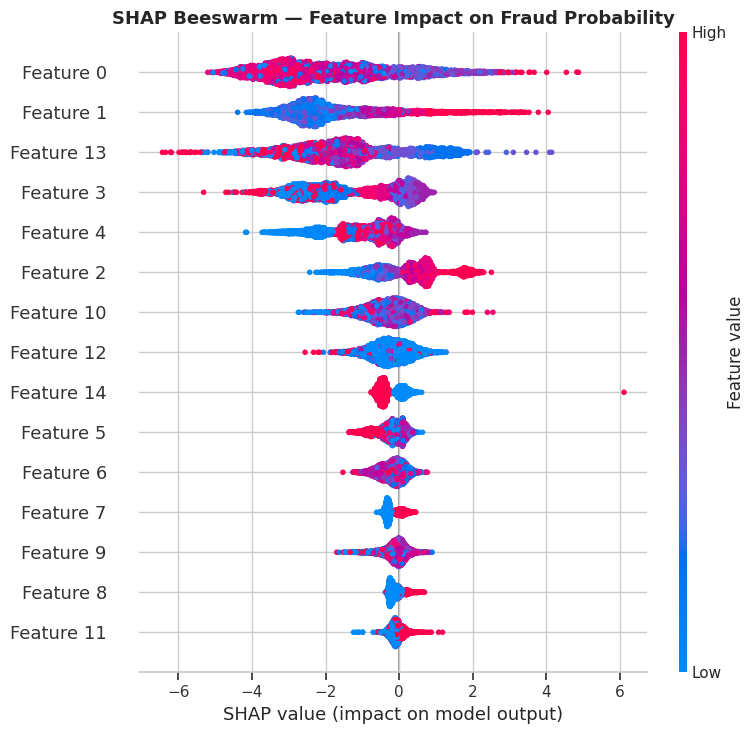

Saved: plots/21_shap_beeswarm.png


In [18]:
# ── Beeswarm plot ──
plt.figure(figsize=(11, 8))
shap.plots.beeswarm(shap_values, max_display=15, show=False)
plt.title('SHAP Beeswarm — Feature Impact on Fraud Probability', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/21_shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plots/21_shap_beeswarm.png')


Explaining sample index 2324
  Actual label     : 1 (fraud)
  Predicted prob   : 1.0000


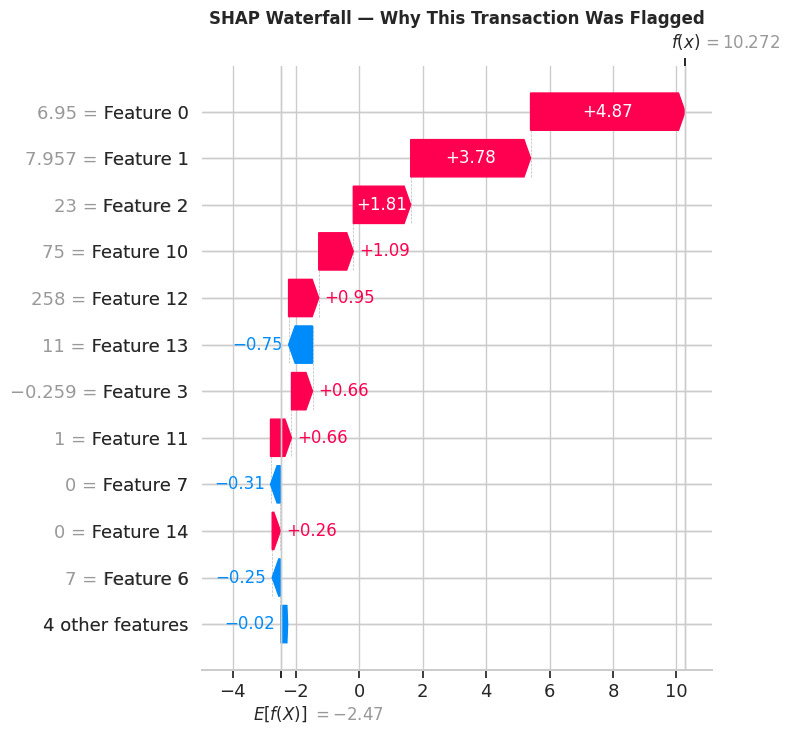

Saved: plots/22_shap_waterfall.png


In [19]:
# ── Waterfall plot — explain a single high-confidence fraud prediction ──
# Find a high-probability fraud case in the SHAP subset
fraud_probs   = best_model.predict_proba(X_shap)[:, 1]
actual_frauds = np.where(y_shap == 1)[0]

if len(actual_frauds) > 0:
    # Pick the fraud case with highest predicted probability
    best_fraud_idx = actual_frauds[np.argmax(fraud_probs[actual_frauds])]
    print(f'Explaining sample index {best_fraud_idx}')
    print(f'  Actual label     : {y_shap[best_fraud_idx]} (fraud)')
    print(f'  Predicted prob   : {fraud_probs[best_fraud_idx]:.4f}')

    plt.figure(figsize=(10, 7))
    shap.plots.waterfall(shap_values[best_fraud_idx], max_display=12, show=False)
    plt.title('SHAP Waterfall — Why This Transaction Was Flagged', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig('plots/22_shap_waterfall.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: plots/22_shap_waterfall.png')
else:
    print('No actual fraud cases in SHAP sample — re-run with larger sample size.')


<Figure size 1000x600 with 0 Axes>

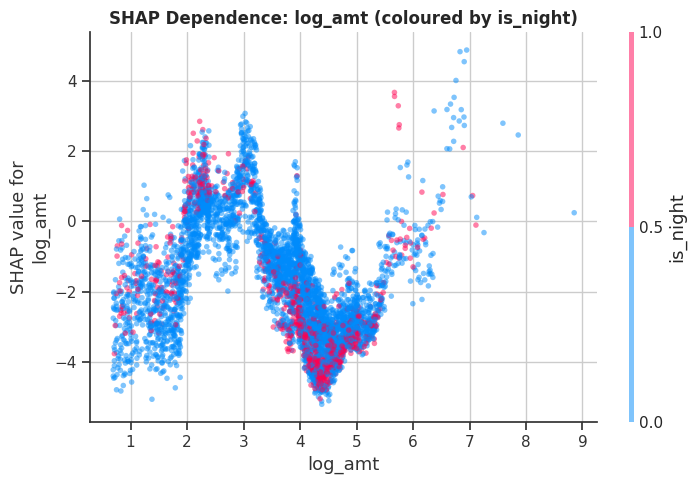

Saved: plots/23_shap_dependence.png


In [20]:
# ── SHAP dependence plot: log_amt coloured by is_night ──
feat_names   = FRAUD_FEATURES
amt_idx      = feat_names.index('log_amt')
night_idx    = feat_names.index('is_night')

plt.figure(figsize=(10, 6))
shap.dependence_plot(
    amt_idx,
    shap_values.values,
    X_shap,
    feature_names=feat_names,
    interaction_index=night_idx,
    show=False,
    alpha=0.5
)
plt.title('SHAP Dependence: log_amt (coloured by is_night)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/23_shap_dependence.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plots/23_shap_dependence.png')


---
## 9. Customer Lifetime Value Regression (Bonus)

> CLV prediction is a regression problem — we're predicting a customer's total future spend,
> not a binary class. We work at the **customer level** using `customer_segments.csv`.
>
> **Target:** `monetary` (total historical spend) as a proxy for CLV.
> In production you'd use forward-looking spend, but this demonstrates the pipeline.
>
> **Model:** XGBoost Regressor with the same hyperparameter search approach.
> We report MAE, RMSE, and R² as evaluation metrics.


In [21]:
# ── Feature set for CLV ──
CLV_FEATURES = [
    'recency', 'frequency', 'avg_txn_amt', 'max_txn_amt', 'std_txn_amt',
    'night_txn_pct', 'weekend_txn_pct', 'unique_merchants',
    'unique_states', 'unique_categories', 'avg_distance_km',
    'customer_age', 'city_pop', 'cluster', 'fraud_flag',
]
CLV_TARGET = 'monetary'

clv_df = seg[CLV_FEATURES + [CLV_TARGET]].dropna()
print(f'CLV dataset: {clv_df.shape}')
print(f'Monetary (CLV proxy) — mean: ${clv_df[CLV_TARGET].mean():,.0f}  '
      f'median: ${clv_df[CLV_TARGET].median():,.0f}  '
      f'max: ${clv_df[CLV_TARGET].max():,.0f}')

X_clv = clv_df[CLV_FEATURES].values
y_clv = np.log1p(clv_df[CLV_TARGET].values)  # log-transform target for better fit

X_clv_train, X_clv_test, y_clv_train, y_clv_test = train_test_split(
    X_clv, y_clv, test_size=0.25, random_state=42
)
print(f'CLV train: {X_clv_train.shape}  |  test: {X_clv_test.shape}')


CLV dataset: (983, 16)
Monetary (CLV proxy) — mean: $92,800  median: $88,514  max: $296,437
CLV train: (737, 15)  |  test: (246, 15)


In [22]:
# ── XGBoost Regressor with quick RandomizedSearch ──
xgb_reg = xgb.XGBRegressor(
    tree_method='hist', device=device, random_state=42
)

reg_param_dist = {
    'n_estimators'    : [200, 400, 600],
    'learning_rate'   : [0.01, 0.05, 0.1],
    'max_depth'       : [3, 4, 5, 6],
    'subsample'       : [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'min_child_weight': [1, 3, 5],
    'reg_alpha'       : [0, 0.1, 1.0],
}

reg_search = RandomizedSearchCV(
    xgb_reg, reg_param_dist, n_iter=20, scoring='r2',
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
        if False else 3,
    refit=True, random_state=42, n_jobs=-1, verbose=1
)

print('Fitting CLV regressor...')
t0 = time.time()
reg_search.fit(X_clv_train, y_clv_train)
print(f'Done in {time.time()-t0:.1f}s  |  Best CV R²: {reg_search.best_score_:.4f}')


Fitting CLV regressor...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Done in 49.4s  |  Best CV R²: 0.9907


MAE : $1,586
RMSE: $2,484
R²  : 0.9967


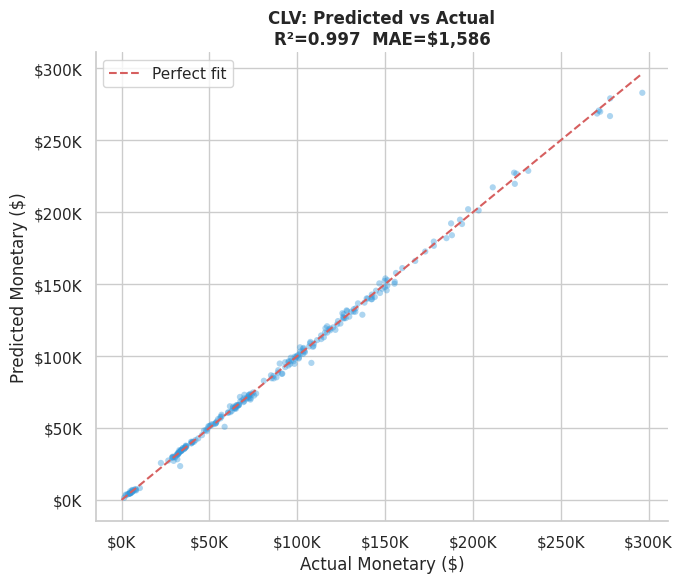

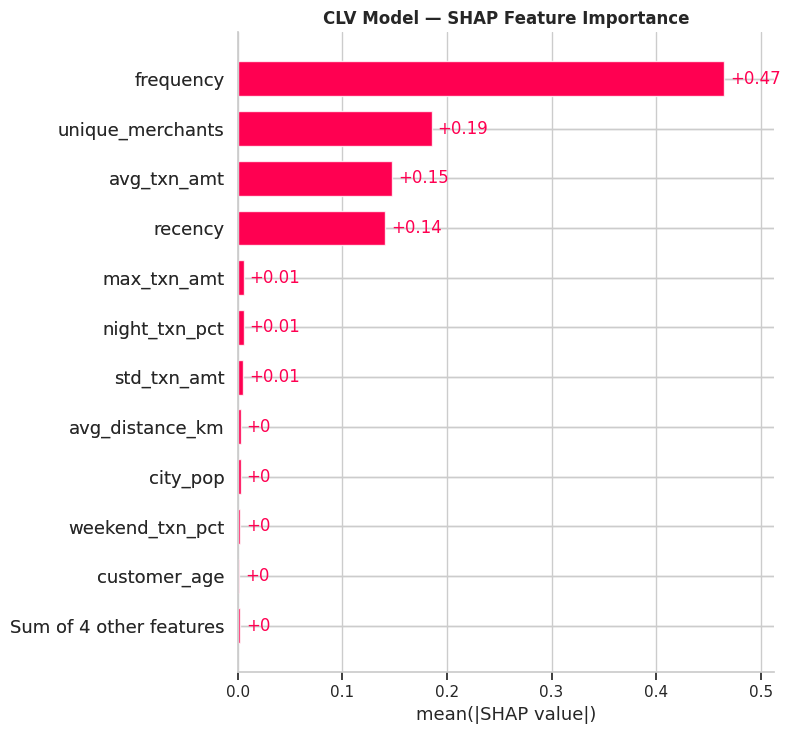

In [28]:
best_reg = reg_search.best_estimator_
y_clv_pred_log = best_reg.predict(X_clv_test)

y_clv_pred = np.expm1(y_clv_pred_log)
y_clv_true = np.expm1(y_clv_test)

mae  = mean_absolute_error(y_clv_true, y_clv_pred)
rmse = np.sqrt(mean_squared_error(y_clv_true, y_clv_pred))
r2   = r2_score(y_clv_test, y_clv_pred_log)

print(f'MAE : ${mae:,.0f}')
print(f'RMSE: ${rmse:,.0f}')
print(f'R²  : {r2:.4f}')

# ── Plot 1: Predicted vs Actual (standalone) ──
fig1, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_clv_true, y_clv_pred, alpha=0.4, s=20, color='#3498db', edgecolors='none')
lims = [0, max(y_clv_true.max(), y_clv_pred.max())]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect fit')
ax.set_xlabel('Actual Monetary ($)')
ax.set_ylabel('Predicted Monetary ($)')
ax.set_title(f'CLV: Predicted vs Actual\nR²={r2:.3f}  MAE=${mae:,.0f}', fontweight='bold')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.legend()
plt.tight_layout()
plt.savefig('plots/24_clv_predicted_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig1)

# ── Plot 2: SHAP bar ──
X_clv_train_df = pd.DataFrame(X_clv_train, columns=CLV_FEATURES)
X_clv_test_df  = pd.DataFrame(X_clv_test,  columns=CLV_FEATURES)

best_reg.fit(X_clv_train_df, y_clv_train)

clv_explainer = shap.TreeExplainer(best_reg)
clv_shap_exp  = clv_explainer(X_clv_test_df)

plt.figure(figsize=(9, 6))
shap.plots.bar(clv_shap_exp, max_display=12, show=False)
plt.title('CLV Model — SHAP Feature Importance', fontweight='bold')
plt.tight_layout()
plt.savefig('plots/24_clv_shap.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 10. Save Models

> We save both models in XGBoost's native `.json` format — lighter than pickle,
> fully portable, and loadable in any language with an XGBoost binding (Python, R, Java, etc.).
> The feature list is saved alongside so you can reconstruct predictions later without
> re-reading this notebook.


In [29]:
# Save fraud classifier
best_model.save_model('fraud_model.json')
print('Saved: fraud_model.json')

# Save CLV regressor
best_reg.save_model('clv_model.json')
print('Saved: clv_model.json')

# Save feature metadata
metadata = {
    'fraud_features'  : FRAUD_FEATURES,
    'clv_features'    : CLV_FEATURES,
    'fraud_threshold' : float(best_threshold),
    'fraud_pr_auc'    : float(pr_auc),
    'fraud_roc_auc'   : float(roc_auc),
    'clv_r2'          : float(r2),
    'clv_mae'         : float(mae),
}

with open('model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print('Saved: model_metadata.json')
print()
print('=== QUICK LOAD EXAMPLE ===')
print("""
import xgboost as xgb, json, numpy as np

with open('model_metadata.json') as f:
    meta = json.load(f)

fraud_model = xgb.XGBClassifier()
fraud_model.load_model('fraud_model.json')

# Score a new transaction
# X_new = np.array([[...]])  # shape (1, len(meta['fraud_features']))
# prob  = fraud_model.predict_proba(X_new)[0, 1]
# flag  = prob >= meta['fraud_threshold']
""")


Saved: fraud_model.json
Saved: clv_model.json
Saved: model_metadata.json

=== QUICK LOAD EXAMPLE ===

import xgboost as xgb, json, numpy as np

with open('model_metadata.json') as f:
    meta = json.load(f)

fraud_model = xgb.XGBClassifier()
fraud_model.load_model('fraud_model.json')

# Score a new transaction
# X_new = np.array([[...]])  # shape (1, len(meta['fraud_features']))
# prob  = fraud_model.predict_proba(X_new)[0, 1]
# flag  = prob >= meta['fraud_threshold']



---
## 11. Phase 3 Summary

### What we built

**Fraud classifier (XGBoost + SMOTE)**
- Trained on 1.3M transaction-level records
- SMOTE resampling to 10:1 legit:fraud ratio
- Tuned via 30-iteration RandomizedSearchCV (3-fold CV, scoring=PR-AUC)
- Evaluated at optimal F1 threshold (not default 0.5)
- SHAP beeswarm + waterfall + dependence plots for explainability

**CLV regressor (XGBoost)**
- Trained at customer level (983 rows)
- Log-transformed target to handle right skew
- SHAP bar chart for feature attribution

### Files produced

| File | Description |
|---|---|
| `fraud_model.json` | Tuned XGBoost fraud classifier |
| `clv_model.json` | XGBoost CLV regressor |
| `model_metadata.json` | Feature lists, thresholds, metric scores |
| `plots/20_model_evaluation.png` | PR curve, ROC, confusion matrix, threshold analysis |
| `plots/21_shap_beeswarm.png` | Global feature importance (SHAP) |
| `plots/22_shap_waterfall.png` | Single prediction explanation |
| `plots/23_shap_dependence.png` | Amount × night interaction |
| `plots/24_clv_model.png` | CLV predicted vs actual + SHAP |

### What Phase 4 (Streamlit app) will use from this notebook
- `fraud_model.json` — real-time fraud scoring interface
- `clv_model.json` — customer value estimator
- `model_metadata.json` — threshold and feature configuration
- SHAP explainer — live waterfall chart on demand for any transaction
- `customer_segments.csv` — segment explorer tab

### Key modelling decisions to mention in interviews
| Decision | Rationale |
|---|---|
| PR-AUC over accuracy | 99.4% accuracy = zero fraud caught on this dataset |
| SMOTE at 10:1 not 1:1 | Full balancing reduces precision; 10:1 preserves signal |
| Cyclical hour encoding | sin/cos prevents model treating 23h and 0h as maximally different |
| amt_z_customer | Contextualises spend relative to that customer's norm |
| Optimal threshold ≠ 0.5 | Threshold should reflect business cost of FP vs FN |
| SHAP over gain importance | Gain shows usage, SHAP shows directional impact per prediction |
